This project applies three distinct causal inference frameworks to real-world economic data, exploring how researchers can move beyond simple correlation to estimate genuine causal effects.
The central questions guiding this work are:
- Does having a small baby in a business outlet reduce monthly profits — and does this hold up after controlling for observable differences between owners?
- Does receiving a government transfer program shape support for that government, and can we isolate this effect using a regression discontinuity design?
- Does subsidizing electricity connection costs increase rural electrification rates in Kenya?

Together, these analyses demonstrate three foundational tools of modern causal inference, difference-in-means testing with OLS controls, regression discontinuity, and randomized treatment arms, applied to questions with direct implications for poverty, public policy, and development economics.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
bpg =pd.read_csv("babyprofitgap_sim.csv")
bpg

,Unnamed: 0,X,Monthly_profits,Ln_monthly_profits,Total_monthly_costs,Ln_total_monthly_costs,Total_monthly_sales,Ln_total_monthly_sales,Business_assets,Borrowed_in_past_year,...,Keeps_records,Num_antimalarials_typically_sold,Avg_price_antimalarials,Times_stock_on_credit,Outlet_sells_malaria_tests,Sole_employee_at_outlet,Business_currently_has_debt,Num_customers_prev_day,Parish_HHI_all_customers,outlet_type
0,1,1,71.319893,4.648001,740.463665,13.041368,122.039904,5.641673,2.108309,0,...,1,2.467586,2.644177,1.866405,0,0,1,19.806201,0,Drug_shop
1,2,2,279.755492,4.361964,460.694251,12.049265,1251.891623,4.988392,1.869069,0,...,1,5.636417,1.883779,-1.634195,0,1,0,18.213709,1,Clinic
2,3,3,253.431850,3.304840,47.771830,11.704664,782.084299,4.487709,1.369953,0,...,1,5.573753,3.436566,0.992106,0,0,0,10.508370,0,Drug_shop
3,4,4,415.111594,4.744696,633.387553,12.298338,614.318501,5.581185,1.526174,1,...,1,4.451980,2.718848,1.176975,1,1,1,31.405428,0,Pharmacy
4,5,5,2.812767,3.865283,195.767800,13.741358,1815.933297,2.366312,1.512629,1,...,1,2.907933,2.947120,0.673212,0,0,0,15.780664,0,Drug_shop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,106,106,148.287825,3.983938,-7.474272,12.543572,1339.206965,4.184314,1.582641,1,...,1,3.684033,3.281695,-0.136892,1,0,0,44.043789,0,Drug_shop
106,107,107,123.765332,3.907424,111.189546,12.426618,702.174427,4.356199,0.770041,1,...,1,5.886866,4.409001,1.556922,1,0,0,24.925023,0,Clinic
107,108,108,58.043347,2.505067,-187.073988,13.327674,631.514205,5.150692,0.748452,0,...,1,4.872691,2.887720,1.885108,0,1,0,20.576920,0,Drug_shop
108,109,109,434.724250,3.823451,756.359871,12.306695,16.652411,5.918041,1.251945,0,...,1,6.355081,4.058904,1.020062,1,0,0,15.037241,1,Drug_shop


In [3]:
bpg.columns

Index(['Unnamed: 0', 'X', 'Monthly_profits', 'Ln_monthly_profits',
       'Total_monthly_costs', 'Ln_total_monthly_costs', 'Total_monthly_sales',
       'Ln_total_monthly_sales', 'Business_assets', 'Borrowed_in_past_year',
       'Access_to_credit', 'Small_baby_in_outlet', 'Age', 'Experience',
       'Legally_qualified', 'Knows_antimalarial', 'Score_on_malaria_test',
       'Cognitive_ability_index', 'Has_other_job', 'Lives_at_outlet',
       'Num_days_worked', 'Hours_worked_per_day', 'Educ_Aide', 'Educ_Student',
       'Educ_Nurse', 'Educ_Pharmacist.Dr', 'Drug_shop', 'Clinic', 'Pharmacy',
       'Age_of_business', 'Keeps_records', 'Num_antimalarials_typically_sold',
       'Avg_price_antimalarials', 'Times_stock_on_credit',
       'Outlet_sells_malaria_tests', 'Sole_employee_at_outlet',
       'Business_currently_has_debt', 'Num_customers_prev_day',
       'Parish_HHI_all_customers', 'outlet_type'],
      dtype='object')

In [4]:
# Create readable group labels
bpg['baby_label'] = bpg['Small_baby_in_outlet'].map({0: 'No baby', 1: 'Baby'})

# Compute summary statistics
sumstats = bpg.groupby('baby_label')['Monthly_profits'].agg(
    mean_profits='mean',
    sd_profits='std',
    n='count'
).reset_index()

# Calculate difference in means (Baby - No baby)
mean_baby = sumstats.loc[sumstats['baby_label'] == 'Baby', 'mean_profits'].iloc[0]
mean_no_baby = sumstats.loc[sumstats['baby_label'] == 'No baby', 'mean_profits'].iloc[0]
difference = mean_baby - mean_no_baby

# Add the difference as a column
sumstats['difference_in_means'] = difference

sumstats

,baby_label,mean_profits,sd_profits,n,difference_in_means
0,Baby,175.444113,119.710133,41,-143.252565
1,No baby,318.696679,235.728542,69,-143.252565


In [5]:
#This means that owners with babies earn less than owners without babies

In [7]:
from scipy import stats

In [8]:
# Monthly profits when there IS a small baby in the outlet
profits_baby = bpg.loc[bpg['Small_baby_in_outlet'] == 1, 'Monthly_profits']

# Monthly profits when there is NO small baby in the outlet
profits_no_baby = bpg.loc[bpg['Small_baby_in_outlet'] == 0, 'Monthly_profits']

# Two-sample t-test (Welch version, does not assume equal variances)
t_stat, p_value = stats.ttest_ind(profits_baby, profits_no_baby, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -4.2153946637104625
p-value: 5.26334287792958e-05


In [9]:
#If the p_value < 0.05, then we can deduce that the two groups' profits are significantly different

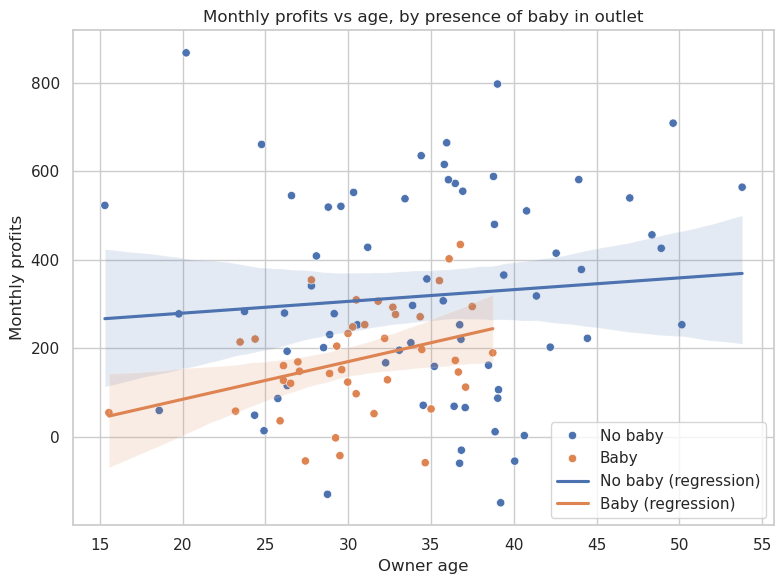

In [10]:
# Make sure we have a readable label
bpg['baby_label'] = bpg['Small_baby_in_outlet'].map({0: 'No baby', 1: 'Baby'})

sns.set(style='whitegrid')

plt.figure(figsize=(8,6))

# Scatter plot, colored by baby presence
sns.scatterplot(
    data=bpg,
    x='Age',
    y='Monthly_profits',
    hue='baby_label'
)

# Add regression line for NO baby
sns.regplot(
    data=bpg[bpg['Small_baby_in_outlet'] == 0],
    x='Age',
    y='Monthly_profits',
    scatter=False,
    label='No baby (regression)'
)

# Add regression line for baby
sns.regplot(
    data=bpg[bpg['Small_baby_in_outlet'] == 1],
    x='Age',
    y='Monthly_profits',
    scatter=False,
    label='Baby (regression)'
)

plt.xlabel('Owner age')
plt.ylabel('Monthly profits')
plt.title('Monthly profits vs age, by presence of baby in outlet')
plt.legend()
plt.tight_layout()
plt.show()

Age can influence both an owner’s profits and the likelihood of having a baby in the outlet. Older owners might run more established businesses and earn higher profits becasue they have more experience, and they are also less likely to have a young child present. Including age as a control helps separate the impact of having a baby from the effects that come simply from being older.

In [11]:
import statsmodels.formula.api as smf

# Model 1: Monthly_profits ~ Small_baby_in_outlet
model1 = smf.ols(
    'Monthly_profits ~ Small_baby_in_outlet',
    data=bpg
).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:        Monthly_profits   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.100
Method:                 Least Squares   F-statistic:                     13.10
Date:                Mon, 24 Nov 2025   Prob (F-statistic):           0.000452
Time:                        02:16:07   Log-Likelihood:                -738.29
No. Observations:                 110   AIC:                             1481.
Df Residuals:                     108   BIC:                             1486.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept              318.6967 

In Model 1, the coefficient on Small_baby_in_outlet is negative and statistically significant, which means that outlets with a baby earn substantially lower monthly profits than those without a baby.

In [12]:
# Model 2
model2 = smf.ols(
    'Monthly_profits ~ Small_baby_in_outlet \
     + Hours_worked_per_day \
     + Times_stock_on_credit \
     + Num_antimalarials_typically_sold \
     + Sole_employee_at_outlet \
     + Age_of_business \
     + I(Age_of_business**2) \
     + C(outlet_type)',
    data=bpg
).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:        Monthly_profits   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.126
Method:                 Least Squares   F-statistic:                     2.743
Date:                Mon, 24 Nov 2025   Prob (F-statistic):            0.00662
Time:                        02:16:11   Log-Likelihood:                -732.45
No. Observations:                 110   AIC:                             1485.
Df Residuals:                     100   BIC:                             1512.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

Model 2 adds controls for hours worked, credit purchases, antimalarial sales, whether the owner is the sole employee, business age, and outlet type. After including these controls, the baby coefficient stays negative and significant, and its size does not change much. This means that the profit gap is not explained by differences in working hours, outlet type, business maturity, or other observable characteristics.

In [15]:
!pip install causaldata 

In [16]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import plotly.express as px
import plotly.graph_objects as go
from causaldata import gov_transfers

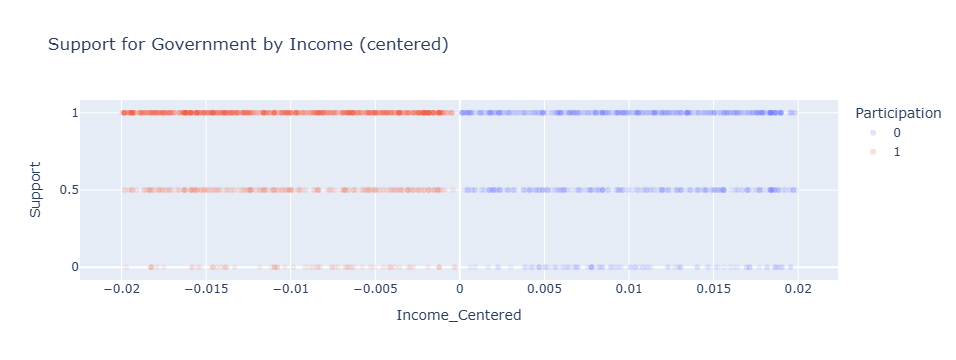

In [17]:
# Load the dataset
gt = gov_transfers.load_pandas().data

# Scatter plot: Income_Centered vs. Support, color by Participation
fig = px.scatter(
    gt,
    x='Income_Centered',
    y='Support',
    color=gt['Participation'].astype(str),
    opacity=0.1,
    labels={'color': 'Participation'},
    title='Support for Government by Income (centered)'
)
fig.show()

In [18]:
# Select numeric variables from gt
num_cols = gt.select_dtypes(include='number').columns

# Means of all numeric variables (1 row, 5 columns)
transfer_means = gt[num_cols].mean(skipna=True).to_frame().T

# Standard deviations of all numeric variables (1 row, 5 columns)
transfer_sds = gt[num_cols].std(skipna=True).to_frame().T

transfer_means, transfer_sds

(   Income_Centered  Education        Age  Participation   Support
 0         -0.00158   4.070623  29.124287       0.578542  0.796201,
    Income_Centered  Education        Age  Participation   Support
 0         0.011631   1.530783  14.428391       0.493919  0.318164)

In [19]:
# Binning Income_Centered data to create bins for mean support
max_income = gt['Income_Centered'].max()
min_income = gt['Income_Centered'].min()
break_count = 30

# Define the bin edges and bin labels
gt['Inc_Bins'] = pd.cut(
    gt['Income_Centered'],
    bins=np.linspace(min_income, max_income, break_count * 2 + 1)
)

# Calculate mean support and income by bin
binned = gt.groupby('Inc_Bins', observed=True).agg(
    support=('Support', 'mean'),
    income=('Income_Centered', 'mean')
).reset_index()

binned.head(15)

,Inc_Bins,support,income
0,"(-0.02, -0.0193]",0.902174,-0.019585
1,"(-0.0193, -0.0187]",0.956522,-0.018961
2,"(-0.0187, -0.018]",0.790698,-0.018299
3,"(-0.018, -0.0173]",0.850000,-0.017654
4,"(-0.0173, -0.0167]",0.900000,-0.017069
5,"(-0.0167, -0.016]",0.904762,-0.016307
6,"(-0.016, -0.0153]",0.842105,-0.015700
7,"(-0.0153, -0.0147]",0.846154,-0.015031
8,"(-0.0147, -0.014]",0.816327,-0.014390
9,"(-0.014, -0.0133]",0.872093,-0.013702


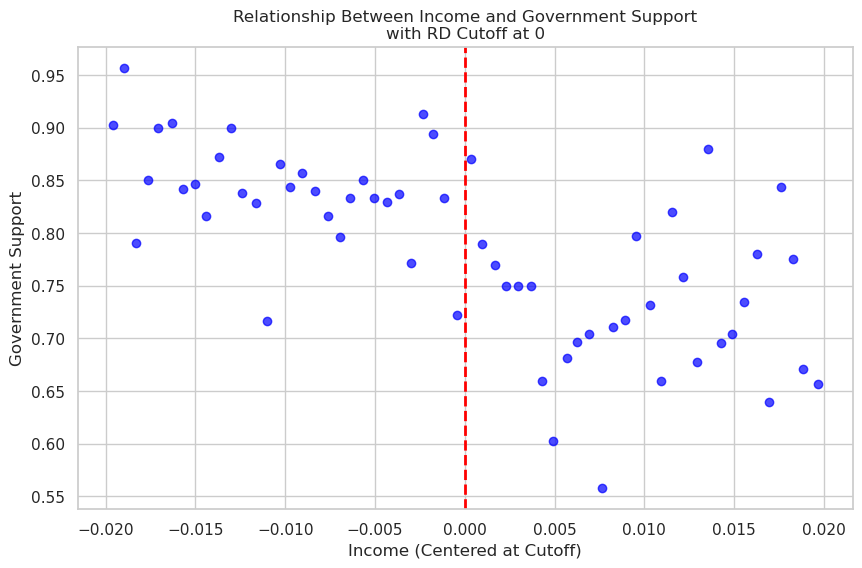

In [20]:
plt.figure(figsize=(10,6))

plt.scatter(binned["income"], binned["support"], color="blue", alpha=0.7)

# Vertical line at cutoff (0)
plt.axvline(x=0, color="red", linestyle="--", linewidth=2)

plt.xlabel("Income (Centered at Cutoff)")
plt.ylabel("Government Support")
plt.title("Relationship Between Income and Government Support\nwith RD Cutoff at 0")
plt.show()

Income_Centered is the variable used as the running variable in the regression discontinuity. It is created by subtracting the cutoff from each person’s income. Values below zero mean income is under the threshold, and values above zero mean income is over it. This lets us compare government support right around the cutoff

In [21]:
import statsmodels.formula.api as smf

gt["treat"] = (gt["Income_Centered"]>= 0).astype(int)

rd = smf.ols(
    "Support ~ treat + Income_Centered",
    data=gt,
).fit()

# Print the summary of the regression
print(rd.summary())

                            OLS Regression Results                            
Dep. Variable:                Support   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     34.28
Date:                Mon, 24 Nov 2025   Prob (F-statistic):           2.34e-15
Time:                        02:16:34   Log-Likelihood:                -499.03
No. Observations:                1948   AIC:                             1004.
Df Residuals:                    1945   BIC:                             1021.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.8357      0.016     

The coefficient on treat is –0.0974. This means that crossing the income cutoff reduces government support by about 9.7 percentage points. The effect is statistically significant (p = 0.001).

In [22]:
re =pd.read_csv("rural_elec_2020.csv")
re.columns

Index(['Unnamed: 0', 'reppid', 'siteno', 'hhid', 'child', 'treat_low',
       'treat_med', 'treat_full', 'treated_all', 'busia', 'base_market',
       'base_population', 'base_connected_rate', 'base_transearly',
       'base_connected', 'base_housing', 'base_bank',
       'base_energyspending_ksh', 'base_female', 'base_age', 'base_educ',
       'base_asset_value_ksh', 'female', 'age_resp', 'child_female',
       'child_age', 'sibs', 'connected', 'gridelec_spending_ksh',
       'electric_lighting', 'number_appliances', 'mobilephone', 'radio',
       'television', 'iron', 'kerosene_spending_ksh', 'energy_spending_ksh',
       'solar_shs', 'fraction_employed_all', 'hours_worked', 'asset_value_ksh',
       'percapcons_ksh', 'symptoms_index', 'life_index', 'st_studenttest',
       'knowledge_index', 'EMI', 'NEMI', 'moved', 'metered', 'survey',
       'round'],
      dtype='object')

In [28]:
pd.DataFrame({
    "column": re.columns,
    "dtype": re.dtypes.values
})


,column,dtype
0,Unnamed: 0,int64
1,reppid,object
2,siteno,int64
3,hhid,int64
4,child,int64
5,treat_low,int64
6,treat_med,int64
7,treat_full,int64
8,treated_all,int64
9,busia,int64


In [29]:
covars = [
    "child",
    "busia",
    "base_market",
    "base_population",
    "base_connected_rate",
    "base_transearly",
    "base_connected",
    "base_housing",
    "base_bank",
    "base_energyspending_ksh",
    "base_female",
    "base_age",
    "base_educ",
    "base_asset_value_ksh",
    "female",
    "age_resp",
    "child_female",
    "child_age",
    "sibs",
    "gridelec_spending_ksh",
    "electric_lighting",
    "number_appliances",
    "mobilephone",
    "radio",
    "television",
    "iron",
    "kerosene_spending_ksh",
    "energy_spending_ksh",
    "solar_shs",
    "fraction_employed_all",
    "hours_worked",
    "asset_value_ksh",
    "percapcons_ksh",
    "symptoms_index",
    "life_index",
    "st_studenttest",
    "knowledge_index",
    "EMI",
    "NEMI",
    "moved",
    "metered"
]
for var in covars:
    print(re[var]

AttributeError: 'Series' object has no attribute 'type'

In [26]:
re['treat_group'] = 'control'
re.loc[re['treat_low'] == 1, 'treat_group'] = 'low'
re.loc[re['treat_med'] == 1, 'treat_group'] = 'medium'
re.loc[re['treat_full'] == 1, 'treat_group'] = 'full'

# Compute summary stats (mean and sd)
summary_stats = re.groupby('treat_group')[covars].agg(['mean', 'std'])

summary_stats

TypeError: agg function failed [how->mean,dtype->object]

In [27]:
re

,Unnamed: 0,reppid,siteno,hhid,child,treat_low,treat_med,treat_full,treated_all,busia,...,life_index,st_studenttest,knowledge_index,EMI,NEMI,moved,metered,survey,round,treat_group
0,1,1101.11,1101,11,0,0,0,0,0,0,...,-0.882125,NaN,0.286758,1.432453,-0.283716,0,NaN,2016-08-18,r1,control
1,2,1101.12,1101,12,0,0,0,0,0,0,...,-1.224506,NaN,-0.841029,-0.164999,-0.593315,0,NaN,2016-08-18,r1,control
2,3,1101.13,1101,13,0,0,0,0,0,0,...,-0.882125,NaN,-0.841029,0.388551,-1.121686,0,NaN,2016-08-18,r1,control
3,4,1101.13.1,1101,13,1,0,0,0,0,0,...,-0.882125,-0.558120,-0.841029,NaN,NaN,0,NaN,2016-08-18,r1,control
4,5,1101.15,1101,15,0,0,0,0,0,0,...,-0.882125,NaN,-0.841029,-1.329135,-0.227484,1,NaN,2016-08-18,r1,control
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3644,3645,2520.25,2520,25,0,0,1,0,1,1,...,1.856926,NaN,-0.841029,0.315009,0.318072,0,NaN,2016-09-08,r1,medium
3645,3646,2520.25.1,2520,25,1,0,1,0,1,1,...,1.856926,-0.332221,-0.841029,NaN,NaN,0,NaN,2016-09-08,r1,medium
3646,3647,2520.27,2520,27,0,0,1,0,1,1,...,-1.224506,NaN,-0.841029,-1.518695,-1.033867,0,NaN,2016-09-21,r1,medium
3647,3648,2520.30,2520,30,0,0,1,0,1,1,...,-0.882125,NaN,-0.841029,0.412059,-0.934352,0,NaN,2016-09-08,r1,medium


In [28]:
# Model 1

import statsmodels.formula.api as smf

model1 = smf.ols(
    "connected ~ treat_low + treat_med + treat_full",
    data=re
).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:              connected   R-squared:                       0.543
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     1444.
Date:                Sun, 23 Nov 2025   Prob (F-statistic):               0.00
Time:                        20:49:51   Log-Likelihood:                -739.35
No. Observations:                3649   AIC:                             1487.
Df Residuals:                    3645   BIC:                             1512.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0547      0.007      7.925      0.0

In [29]:
model2 = smf.ols(
    "connected ~ treat_low + treat_med + treat_full + female + age_resp + asset_value_ksh",
    data=re
).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:              connected   R-squared:                       0.565
Model:                            OLS   Adj. R-squared:                  0.564
Method:                 Least Squares   F-statistic:                     788.7
Date:                Sun, 23 Nov 2025   Prob (F-statistic):               0.00
Time:                        20:49:53   Log-Likelihood:                -649.35
No. Observations:                3649   AIC:                             1313.
Df Residuals:                    3642   BIC:                             1356.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0082      0.019     

In [30]:
re['child_age'].isna().sum()

np.int64(2217)

In [31]:
model3 = smf.ols("treated_all ~ treat_low + treat_med + treat_full + "
    "child + busia + base_market + base_population + base_connected_rate + "
    "base_transearly + base_connected + base_housing + base_bank + "
    "base_energyspending_ksh + base_female + base_age + base_educ + "
    "base_asset_value_ksh + female + age_resp + sibs + "
    "gridelec_spending_ksh + electric_lighting + number_appliances + "
    "mobilephone + radio + television + iron + kerosene_spending_ksh + "
    "energy_spending_ksh + solar_shs + fraction_employed_all + hours_worked + "
    "asset_value_ksh + percapcons_ksh + symptoms_index + life_index + "
    "knowledge_index + moved",
    data=re
).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:            treated_all   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.549e+22
Date:                Sun, 23 Nov 2025   Prob (F-statistic):               0.00
Time:                        20:49:55   Log-Likelihood:                 78469.
No. Observations:                3479   AIC:                        -1.569e+05
Df Residuals:                    3441   BIC:                        -1.566e+05
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept               -2